In [ ]:
import pandas as pd

df_incendios = pd.read_csv("Actividad 2.1 Incendios.csv")
df_incendios.head()

,id,superficie,fecha,idcomunidad,idprovincia,idmunicipio,municipio,causa,causa_supuesta,causa_desc,muertos,heridos,time_ctrl,time_ext,personal,medios,gastos,perdidas
0,1968290001,140,01/01/1968,4,29,0,INDETERMINADO,2,1,40,0,0,0,360,0,0,0,0
1,1968430003,30,03/01/1968,2,43,0,INDETERMINADO,5,1,0,0,0,0,60,0,0,0,0
2,1968290006,20,06/01/1968,4,29,0,INDETERMINADO,5,1,0,0,0,0,120,0,0,0,0
3,1968120007,82,07/01/1968,9,12,0,INDETERMINADO,3,1,20,0,0,0,120,0,0,0,0
4,1968430016,6000,07/01/1968,2,43,0,INDETERMINADO,3,1,20,0,0,0,1440,35,1,0,0


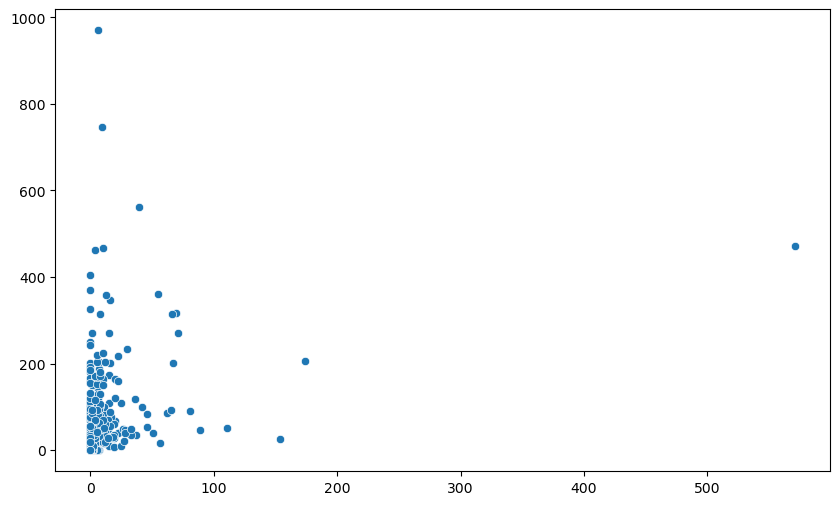

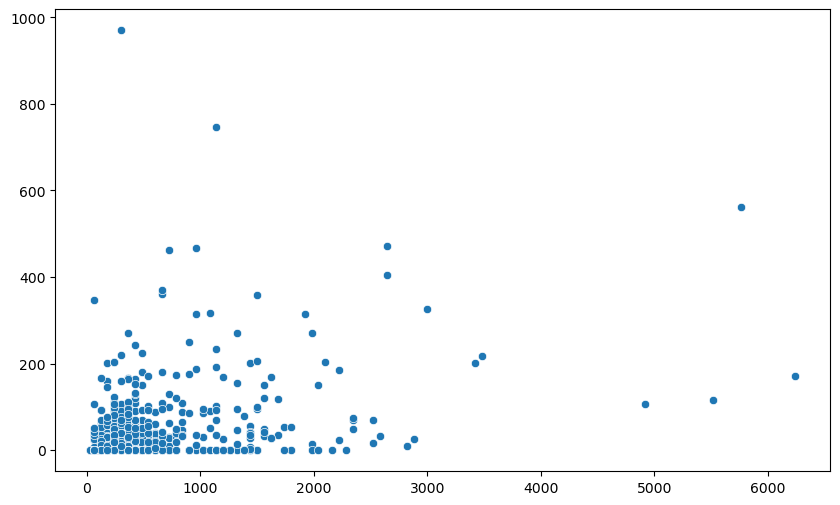

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

df_incendios = df_incendios.sort_values("superficie", ascending=True)
df_incendios = df_incendios[0:1000]

plt.figure(figsize=(10, 6))
sns.scatterplot(x="perdidas", y="personal", data=df_incendios)
plt.title("")
plt.xlabel("")
plt.ylabel("")
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(x="time_ext", y="personal", data=df_incendios)
plt.title("")
plt.xlabel("")
plt.ylabel("")
plt.show()

In [24]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

x = df_incendios[["perdidas", "time_ext"]]
y = df_incendios["personal"]

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size = 0.2, random_state = 42
)

In [25]:
modelo = LinearRegression()
modelo.fit(x_train, y_train)

LinearRegression()

In [26]:
pd.DataFrame({
    "Variable": x.columns,
    "Coeficiente": modelo.coef_
})

,Variable,Coeficiente
0,perdidas,0.808533
1,time_ext,0.040365


In [27]:
y_pred = modelo.predict(x_test)

r2 = r2_score(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("R2: ", r2)
print("MAE: ", mae)
print("MSE: ", mse)

R2:  0.11392457764532227
MAE:  35.059726510540465
MSE:  7466.681106499211
